# H2-DRI-EAF steel NPV simulation

Run the Monte Carlo simulation for H2-DRI-EAF steel and visualize its total NPV, LNM, and LCOS (steel LCOX) distributions. The NPV summary also reports the number and share of simulations with non-negative versus negative NPV.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from steel.steel_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_RETROFIT_BAU_MODE,
    DEFAULT_SAMPLE_SIZE,
    simulate_steel_results,
)

from npv_summary import summarize_metric_signs
from npv_summary_plots import plot_financial_metric_distribution


In [2]:
TECHNOLOGY = "h2_dri_eaf"
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED
RETROFIT_BAU_MODE = DEFAULT_RETROFIT_BAU_MODE

results_by_technology = simulate_steel_results(
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    technologies=(TECHNOLOGY,),
    retrofit_bau_mode=RETROFIT_BAU_MODE,
)
simulation = results_by_technology[TECHNOLOGY]
results = pd.DataFrame(simulation)
results.head()


,run_id,technology,technology_type,retrofit_bau_mode,annual_output_tcs,lifetime_years,capex_eur_per_tcs,fixed_opex_eur_per_tcs,variable_opex_eur_per_tcs,fuel_type,...,annual_electricity_cost_eur,annual_transport_and_storage_cost_eur,annual_emissions_cost_eur,annual_total_cost_eur,annual_net_cash_flow_eur,npv_eur,discounted_lifetime_output_tcs,present_value_total_cost_eur,lcos_eur_per_tcs,levelized_net_margin_eur_per_tcs
0,0,h2_dri_eaf,absolute,not_applicable,1000000.0,20.0,555.076927,31.307673,327.485129,green_hydrogen_and_charcoal,...,9.823995e+07,0.0,522174.697998,8.696380e+08,-4.196380e+08,-4.675144e+09,9.818147e+06,9.093311e+09,926.173783,-476.173783
1,1,h2_dri_eaf,absolute,not_applicable,1000000.0,20.0,604.560048,28.487212,334.638833,green_hydrogen_and_charcoal,...,1.164604e+08,0.0,597905.554108,8.680551e+08,-4.180551e+08,-4.709087e+09,9.818147e+06,9.127253e+09,929.630925,-479.630925
2,2,h2_dri_eaf,absolute,not_applicable,1000000.0,20.0,490.933225,33.324220,335.095904,green_hydrogen_and_charcoal,...,1.470767e+08,0.0,660892.282419,8.848568e+08,-4.348568e+08,-4.760422e+09,9.818147e+06,9.178588e+09,934.859456,-484.859456
3,3,h2_dri_eaf,absolute,not_applicable,1000000.0,20.0,504.859819,33.869009,324.679108,green_hydrogen_and_charcoal,...,1.930478e+08,0.0,590178.383268,9.811533e+08,-5.311533e+08,-5.719801e+09,9.818147e+06,1.013797e+10,1032.574384,-582.574384
4,4,h2_dri_eaf,absolute,not_applicable,1000000.0,20.0,716.098208,29.962332,351.716045,green_hydrogen_and_charcoal,...,1.563174e+08,0.0,699001.142581,9.400193e+08,-4.900193e+08,-5.527180e+09,9.818147e+06,9.945347e+09,1012.955523,-562.955523


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
lcos_eur_per_tcs = results["lcos_eur_per_tcs"]
levelized_net_margin_eur_per_tcs = results["levelized_net_margin_eur_per_tcs"]

summary = pd.concat(
    [
        npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR"
        ),
        lcos_eur_per_tcs.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "LCOS EUR/tCS"
        ),
        levelized_net_margin_eur_per_tcs.describe(
            percentiles=[0.05, 0.5, 0.95]
        ).rename("Levelized net margin EUR/tCS"),
    ],
    axis=1,
)

npv_signs = summarize_metric_signs(npv_million_eur)
npv_sign_summary = pd.DataFrame(
    {
        "NPV category": ["Non-negative (NPV >= 0)", "Negative (NPV < 0)"],
        "Simulation count": [
            npv_signs["non_negative_count"],
            npv_signs["negative_count"],
        ],
        "Simulation share": [
            npv_signs["non_negative_share"],
            1.0 - npv_signs["non_negative_share"],
        ],
    }
)

display(summary)
display(npv_sign_summary)


,NPV million EUR,LCOS EUR/tCS,Levelized net margin EUR/tCS
count,100000.000000,100000.000000,100000.000000
mean,-5380.986002,998.065310,-548.065310
std,594.574178,60.558693,60.558693
min,-7775.193731,813.987043,-791.920656
5%,-6409.985841,902.451935,-652.871216
50%,-5354.750089,995.393124,-545.393124
95%,-4442.239794,1102.871216,-452.451935
max,-3573.678447,1241.920656,-363.987043


,NPV category,Simulation count,Simulation share
0,Non-negative (NPV >= 0),0,0.0
1,Negative (NPV < 0),100000,1.0


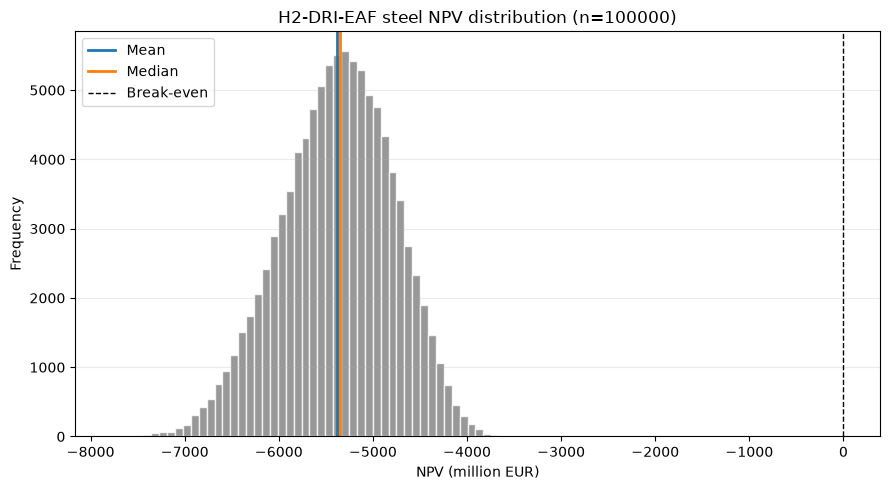

In [4]:
plot_financial_metric_distribution(
    npv_million_eur,
    title=f"H2-DRI-EAF steel NPV distribution (n={SAMPLE_SIZE})",
    x_axis_label="NPV (million EUR)",
    color="tab:gray",
    show_break_even=True,
)
plt.show()


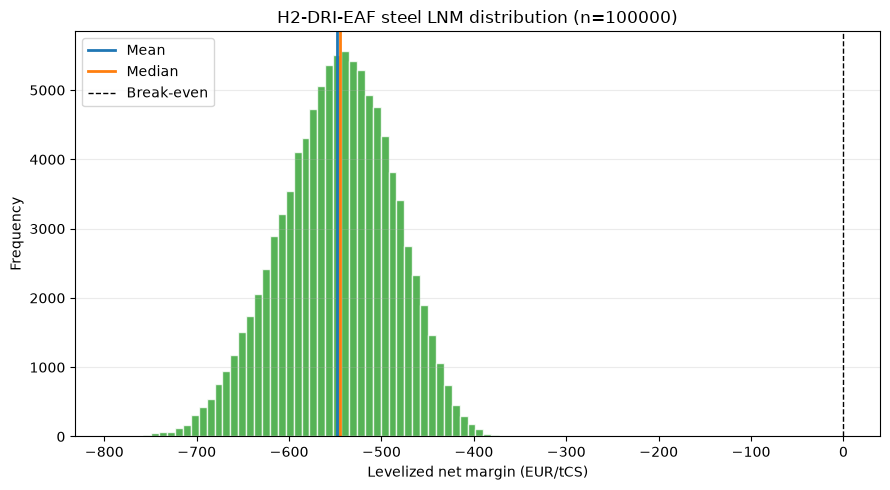

In [5]:
plot_financial_metric_distribution(
    levelized_net_margin_eur_per_tcs,
    title=f"H2-DRI-EAF steel LNM distribution (n={SAMPLE_SIZE})",
    x_axis_label="Levelized net margin (EUR/tCS)",
    color="tab:green",
    show_break_even=True,
)
plt.show()


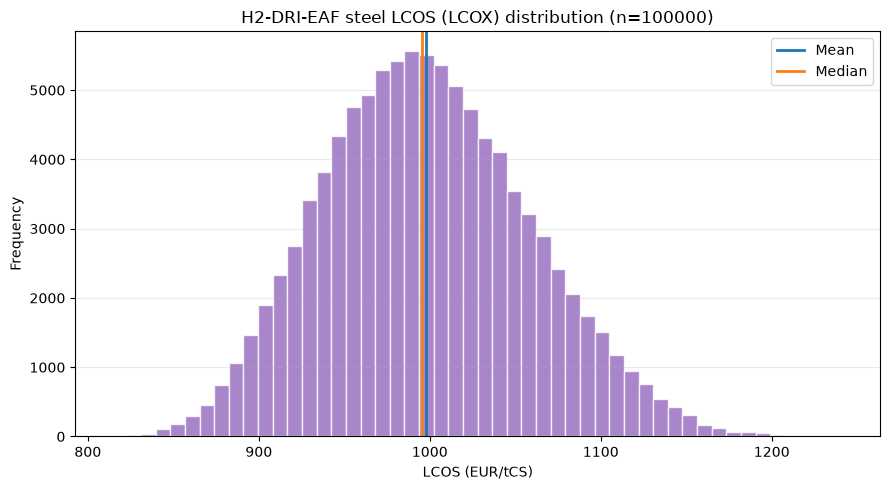

In [6]:
plot_financial_metric_distribution(
    lcos_eur_per_tcs,
    title=f"H2-DRI-EAF steel LCOS (LCOX) distribution (n={SAMPLE_SIZE})",
    x_axis_label="LCOS (EUR/tCS)",
    color="tab:purple",
)
plt.show()


In [7]:
annual_components = results[
    [
        "annual_revenue_eur",
        "annual_fixed_opex_eur",
        "annual_variable_opex_eur",
        "annual_fuel_cost_eur",
        "annual_electricity_cost_eur",
        "annual_emissions_cost_eur",
        "annual_net_cash_flow_eur"
    ]
] / 1_000_000

annual_components.mean().rename("Mean annual value, million EUR")


annual_revenue_eur             450.000000
annual_fixed_opex_eur           31.001786
annual_variable_opex_eur       334.598567
annual_fuel_cost_eur           406.958261
annual_electricity_cost_eur    164.701351
annual_emissions_cost_eur        0.533834
annual_net_cash_flow_eur      -487.793799
Name: Mean annual value, million EUR, dtype: float64